In [1]:
# Install required library
!pip install -q sentence-transformers matplotlib seaborn numpy

from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Task 4.1: exactly 10 sentences across 3 topics
sentences = [
    # Cricket (4 sentences)
    "The bowler took three wickets in one over.",
    "The captain won the toss and chose to bat first.",
    "A century by the opening batsman changed the game.",
    "The spinner turned the ball sharply on the dry pitch.",
    # Cooking (3 sentences)
    "I marinated the chicken in herbs and lemon overnight.",
    "The pastry needs to chill for at least one hour before baking.",
    "Mix the onions, garlic, and tomatoes to make a rich sauce.",
    # Cybersecurity (3 sentences)
    "The team detected a phishing attack targeting the finance department.",
    "Two-factor authentication blocks most password reuse attacks.",
    "A security patch was deployed immediately after the vulnerability report."
]

print('Total sentences:', len(sentences))
for i, s in enumerate(sentences, start=1):
    print(f"{i}. {s}")

# Generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print('\nEmbeddings shape:', embeddings.shape)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Adhik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\Adhik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


Total sentences: 10
1. The bowler took three wickets in one over.
2. The captain won the toss and chose to bat first.
3. A century by the opening batsman changed the game.
4. The spinner turned the ball sharply on the dry pitch.
5. I marinated the chicken in herbs and lemon overnight.
6. The pastry needs to chill for at least one hour before baking.
7. Mix the onions, garlic, and tomatoes to make a rich sauce.
8. The team detected a phishing attack targeting the finance department.
9. Two-factor authentication blocks most password reuse attacks.
10. A security patch was deployed immediately after the vulnerability report.


C:\Users\Adhik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Adhik\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading w


Embeddings shape: (10, 384)


Cosine similarity matrix (10x10):
        S1     S2     S3     S4     S5     S6     S7     S8     S9    S10
S1   1.000  0.525  0.520  0.381  0.041 -0.003  0.126  0.074  0.011  0.119
S2   0.525  1.000  0.548  0.467  0.034  0.036  0.023  0.047  0.014  0.055
S3   0.520  0.548  1.000  0.380  0.013 -0.073 -0.024  0.064  0.068  0.150
S4   0.381  0.467  0.380  1.000  0.145  0.144  0.123  0.029 -0.018  0.036
S5   0.041  0.034  0.013  0.145  1.000  0.216  0.443 -0.007 -0.027  0.109
S6  -0.003  0.036 -0.073  0.144  0.216  1.000  0.211 -0.060 -0.071  0.150
S7   0.126  0.023 -0.024  0.123  0.443  0.211  1.000 -0.013 -0.064  0.014
S8   0.074  0.047  0.064  0.029 -0.007 -0.060 -0.013  1.000  0.211  0.311
S9   0.011  0.014  0.068 -0.018 -0.027 -0.071 -0.064  0.211  1.000  0.177
S10  0.119  0.055  0.150  0.036  0.109  0.150  0.014  0.311  0.177  1.000


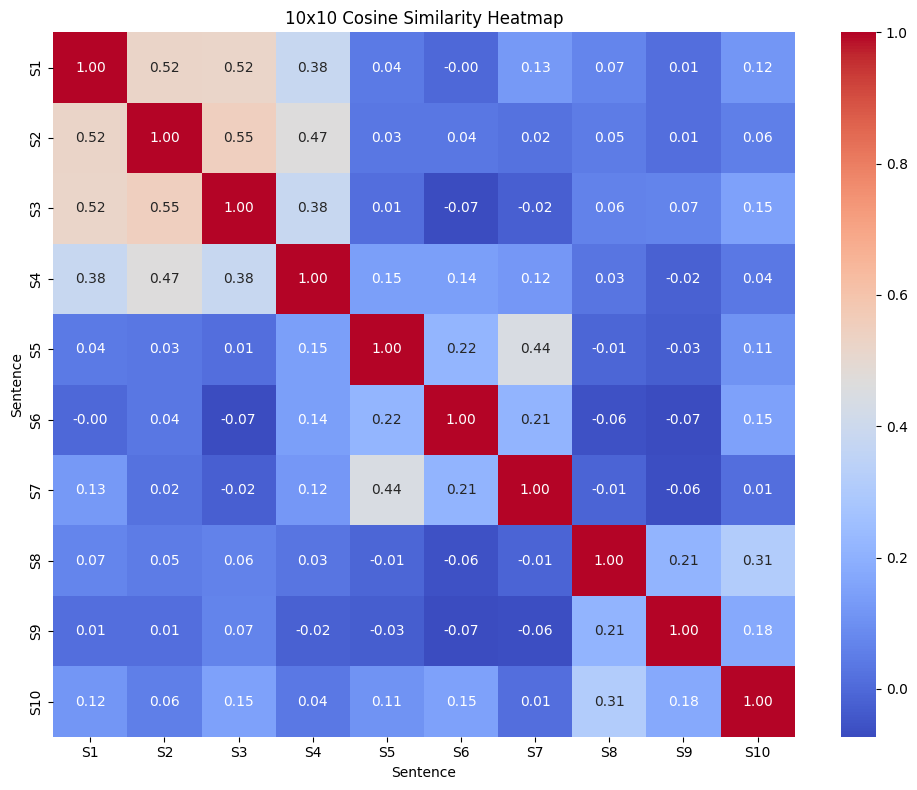

In [2]:
# Cosine similarity matrix
sim_matrix = cosine_similarity(embeddings)

# Display similarity matrix
df_sim = pd.DataFrame(sim_matrix, columns=[f'S{i}' for i in range(1, 11)], index=[f'S{i}' for i in range(1, 11)])
print('Cosine similarity matrix (10x10):')
print(df_sim.round(3))

# Heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(df_sim, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('10x10 Cosine Similarity Heatmap')
plt.xlabel('Sentence')
plt.ylabel('Sentence')
plt.tight_layout()
plt.show()

In [3]:
# Query sentence and top 2 most similar from set
query = "The bowler took three wickets in one over"
query_embed = model.encode([query])

query_scores = cosine_similarity(query_embed, embeddings)[0]
ranked_idx = np.argsort(query_scores)[::-1]

print('Query:', query)
print('\nTop 2 similar sentences:')
for rank in range(2):
    idx = ranked_idx[rank]
    print(f"{rank+1}. Sentence index {idx+1} (score: {query_scores[idx]:.4f})")
    print('   ', sentences[idx])

print('\nAll similarity scores:')
for idx in ranked_idx[:5]:
    print(f"   S{idx+1}: {query_scores[idx]:.4f} -- {sentences[idx]}")

Query: The bowler took three wickets in one over

Top 2 similar sentences:
1. Sentence index 1 (score: 0.9914)
    The bowler took three wickets in one over.
2. Sentence index 2 (score: 0.5077)
    The captain won the toss and chose to bat first.

All similarity scores:
   S1: 0.9914 -- The bowler took three wickets in one over.
   S2: 0.5077 -- The captain won the toss and chose to bat first.
   S3: 0.4936 -- A century by the opening batsman changed the game.
   S4: 0.3798 -- The spinner turned the ball sharply on the dry pitch.
   S7: 0.1221 -- Mix the onions, garlic, and tomatoes to make a rich sauce.
